# INF2229 : Informatique et Gestion de donnée
## Projet : Qualité des données IoT et Maintenance

In [1]:
# Import des moduls/packages necessaire pour le travail
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import folium

## PARTIE 3 – Détection d’anomalies dans les données météo

In [2]:
meteo_df = pd.read_csv("capteurs_meteo_enrichis.csv")
print(f"Nombre de lignes : {meteo_df.shape[0]}")
print(f"Nombre de colonnes : {meteo_df.shape[1]}")
meteo_df.head()

Nombre de lignes : 60000
Nombre de colonnes : 14


,id_capteur,zone,latitude,longitude,date_heure,temperature_air,humidite_air,pression,vitesse_vent,direction_vent,pluviometrie,altitude,precision_gps,etat_capteur
0,MA01,Zone A,14.1748,-6.8569,2025-04-01 01:00:00,33.9,50.5,1010.0,14.4,SO,1.58,179.4,3.1,OK
1,MA01,Zone A,14.1748,-6.8569,2025-04-01 02:00:00,36.1,71.9,1020.6,15.8,SE,2.84,179.4,1.3,OK
2,MA01,Zone A,14.1748,-6.8569,2025-04-01 05:00:00,34.5,59.1,1017.8,8.2,SE,0.46,179.4,1.9,OK
3,MA01,Zone A,14.1748,-6.8569,2025-04-01 06:00:00,31.4,69.5,1009.6,25.7,S,1.02,179.4,2.3,OK
4,MA01,Zone A,14.1748,-6.8569,2025-04-01 08:00:00,30.5,70.9,1011.2,14.4,E,4.23,179.4,1.4,OK


Nous avons chargé un dataset contenant les données des capters météo. Ce dataset est constituée de **14** colonnes/caractéristiques et contient **60000** lignes.

#### Verification des valeurs manquantes

In [3]:
meteo_df.isnull().sum()

id_capteur         0
zone               0
latitude           0
longitude          0
date_heure         0
temperature_air    0
humidite_air       0
pression           0
vitesse_vent       0
direction_vent     0
pluviometrie       0
altitude           0
precision_gps      0
etat_capteur       0
dtype: int64

Aucune valeur manquante détectée

#### Valeurs uniques
Le comptage du nombre de valeurs unique nous permettra de comprendre la variabilité des valeurs de chaque colonne dans nos donnée.

In [4]:
meteo_df.nunique()

id_capteur           52
zone                  4
latitude             52
longitude            52
date_heure         2927
temperature_air     852
humidite_air        938
pression            700
vitesse_vent       1571
direction_vent        8
pluviometrie       3910
altitude             52
precision_gps        41
etat_capteur          3
dtype: int64

À première vue, nous observons que le jeu de données contient **52** capteurs répartis sur **4** zones différentes.La colonne `date_heure` contient **2927** valeurs distinctes, indiquant une collecte de données réalisée sur une période importante avec de nombreux relevés dans le temps.

Les variables météorologiques présentent une forte variabilité, notamment la pluviométrie avec **3910** valeurs distinctes, la vitesse du vent avec **1571** valeurs et l’humidité de l’air avec **938** valeurs, ce qui montre des fluctuations importantes. 

La température de l’air avec **852** valeurs et la pression avec **700** valeurs présentent également une variabilité mais de manière plus modérée.

La direction du vent ne contient que **8** valeurs distinctes. Enfin tandis que `etat_capteur` avec 3 états montre que les capteurs peuvent se trouver dans trois conditions de fonctionnement différentes.

In [5]:
meteo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_capteur       60000 non-null  object 
 1   zone             60000 non-null  object 
 2   latitude         60000 non-null  float64
 3   longitude        60000 non-null  float64
 4   date_heure       60000 non-null  object 
 5   temperature_air  60000 non-null  float64
 6   humidite_air     60000 non-null  float64
 7   pression         60000 non-null  float64
 8   vitesse_vent     60000 non-null  float64
 9   direction_vent   60000 non-null  object 
 10  pluviometrie     60000 non-null  float64
 11  altitude         60000 non-null  float64
 12  precision_gps    60000 non-null  float64
 13  etat_capteur     60000 non-null  object 
dtypes: float64(9), object(5)
memory usage: 6.4+ MB


On distingue deux type de valeurs dans notre dataset : le type `object` qui est associé au variables catégorielles et le type `float` (decimal) qui est associé au mesures, c'est à dire les varibles quantitstives **continues**.

La colonne `date_heure` est identifier comme une variable categorielle alors qu'il s'agie d'une variable **temporelle**. Nous allons la convertire dans le bon format pour la suite.

In [6]:
meteo_df['date_heure'] = pd.to_datetime(meteo_df['date_heure'])
meteo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_capteur       60000 non-null  object        
 1   zone             60000 non-null  object        
 2   latitude         60000 non-null  float64       
 3   longitude        60000 non-null  float64       
 4   date_heure       60000 non-null  datetime64[ns]
 5   temperature_air  60000 non-null  float64       
 6   humidite_air     60000 non-null  float64       
 7   pression         60000 non-null  float64       
 8   vitesse_vent     60000 non-null  float64       
 9   direction_vent   60000 non-null  object        
 10  pluviometrie     60000 non-null  float64       
 11  altitude         60000 non-null  float64       
 12  precision_gps    60000 non-null  float64       
 13  etat_capteur     60000 non-null  object        
dtypes: datetime64[ns](1), float64(9), obje

In [7]:
numeric_cols = meteo_df.select_dtypes(include='number').columns.tolist()
categorial_cols = meteo_df.select_dtypes(include='object').columns.tolist()
time_cols = meteo_df.select_dtypes(include='datetime64[ns]').columns.tolist()

print(f"Liste des variables numériques : {numeric_cols}")
print(f"Liste des variables catégorielles : {categorial_cols}")
print(f"Liste des variables temporelles : {time_cols}")

Liste des variables numériques : ['latitude', 'longitude', 'temperature_air', 'humidite_air', 'pression', 'vitesse_vent', 'pluviometrie', 'altitude', 'precision_gps']
Liste des variables catégorielles : ['id_capteur', 'zone', 'direction_vent', 'etat_capteur']
Liste des variables temporelles : ['date_heure']


### 10. Boxplot de pluviométrie et `vitesse_vent`

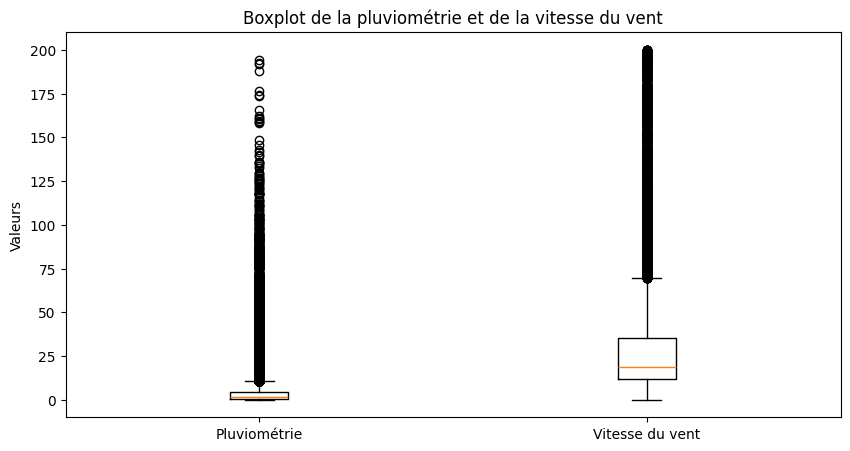

In [8]:
# Création de la figure
plt.figure(figsize=(10, 5))

# Données
data = [
    meteo_df["pluviometrie"].dropna(),
    meteo_df["vitesse_vent"].dropna()
]

plt.boxplot(data, tick_labels=["Pluviométrie", "Vitesse du vent"])

plt.title("Boxplot de la pluviométrie et de la vitesse du vent")
plt.ylabel("Valeurs")

plt.show()

### 11. Identification des outliers via la méthode IQR

In [9]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

In [10]:
outliers_pluie, low_p, up_p = detect_outliers_iqr(meteo_df, "pluviometrie")
print("Pluviométrie - bornes :", low_p, up_p)
print("Nombre d'outliers :", len(outliers_pluie))

outliers_vent, low_v, up_v = detect_outliers_iqr(meteo_df, "vitesse_vent")
print("Vitesse du vent - bornes :", low_v, up_v)
print("Nombre d'outliers :", len(outliers_vent))

Pluviométrie - bornes : -5.805000000000001 10.795000000000002
Nombre d'outliers : 6685
Vitesse du vent - bornes : -22.650000000000006 69.75
Nombre d'outliers : 2097


La quantité de données abérantes est assez remarquable. En fonction de la pluviométries, nous constatons **6685** outliers et en ce qui concerne la vitesse de vent, nous avons **2097**. Ceci suggère soit des mesures erronnées soit des évenement climatiques assez fréquants.

In [11]:
capteurs_outliers_pluie = (
    outliers_pluie["id_capteur"]
    .value_counts()
    .reset_index()
)

capteurs_outliers_pluie.columns = ["id_capteur", "nb_outliers_pluie"]

capteurs_outliers_pluie

,id_capteur,nb_outliers_pluie
0,MD04,380
1,MD09,353
2,MD10,348
3,MD02,346
4,MD08,339
5,MD03,338
6,MD05,337
7,MD01,335
8,MD06,328
9,MD07,319


In [12]:
capteurs_outliers_vent = (
    outliers_vent["id_capteur"]
    .value_counts()
    .reset_index()
)

capteurs_outliers_vent.columns = ["id_capteur", "nb_outliers_vent"]

capteurs_outliers_vent

,id_capteur,nb_outliers_vent
0,MD09,149
1,MD04,145
2,MD05,143
3,MD07,138
4,MD02,133
5,MD06,132
6,MD03,132
7,MD08,126
8,MD10,126
9,MD01,99


Lorsqu'on fait resortire les capteur concernées, on remarque dans les deux cas que les capteur qui ont enregistrés le plus de données abérantes sont ceux de la zones D, puis ceux de la zone C et B moyennement et de maniere tres faible ceux de la zone A.

### Discussion : s’agit-il d’erreurs ou d’événements rares?

Pourn le savoir, nous allons tout d'abord vérifier les evenement qui ont eu lieux sur les mêmes date que celles des données abérante, puis vérifier également les état des capteurs concernée.

In [29]:
event_df = pd.read_csv("evenements_locaux.csv")
event_df

,date,zone,type_evenement,description
0,2025-04-10,Zone A,Orage,Orage avec éclairs et précipitations intenses
1,2025-06-05,Zone A,Sécheresse,"Début de sécheresse, humidité sol < 15%"
2,2025-06-18,Zone A,Sécheresse,"Sécheresse persistante, stress hydrique sur cu..."
3,2025-06-30,Zone A,Alerte chaleur,Température > 38°C relevée à l'ombre
4,2025-07-12,Zone A,Reprise pluies,Premières pluies après 6 semaines de sécheresse
5,2025-04-11,Zone B,Pluies,Pluies continues toute la journée
6,2025-07-01,Zone B,Inondation,"Débordement rivière, rues submergées"
7,2025-07-05,Zone B,Inondation,"Évacuations locales, capteurs immergés"
8,2025-07-10,Zone B,Maintenance,Opération de maintenance massive post-inondation
9,2025-07-20,Zone B,Retour normal,"Eaux en recul, reprise progressive des mesures"


Le fichier `evenements_locaux.csv` contient des événements météorologiques (orages, sécheresses, etc.) datés et localisés par zone. Nous allons convertir la colonne `date` au bon format puis croiser ces événements avec les dates et zones des valeurs aberrantes détectées.

In [30]:
event_df["date"] = pd.to_datetime(event_df["date"])
event_df["type_evenement"].value_counts()

type_evenement
Vent fort         5
Tempête           3
Maintenance       2
Sécheresse        2
Orage             2
Alerte            2
Inondation        2
Alerte chaleur    1
Reprise pluies    1
Pluies            1
Retour normal     1
Grêle             1
Post-tempête      1
Name: count, dtype: int64

#### Croisement des outliers avec les événements locaux

Nous ajoutons une colonne `date` (sans l'heure) aux outliers, puis nous effectuons une jointure avec les événements sur la paire (`date`, `zone`). Un outlier est considéré comme **explicable** par un événement si la même zone est touchée par un événement climatique le même jour.

In [31]:
def croiser_avec_evenements(outliers, events):
    out = outliers.copy()
    out["date"] = out["date_heure"].dt.normalize()
    merged = out.merge(events, on=["date", "zone"], how="left", indicator=True)
    merged["explique_par_evenement"] = merged["_match"] = (merged["_merge"] == "both")
    return merged.drop(columns=["_merge", "_match"])

outliers_pluie_evt = croiser_avec_evenements(outliers_pluie, event_df)
outliers_vent_evt = croiser_avec_evenements(outliers_vent, event_df)

print("Pluviométrie :")
print(f"  Outliers expliqués par un événement : {outliers_pluie_evt['explique_par_evenement'].sum()} / {len(outliers_pluie)}")
print(f"  Soit {outliers_pluie_evt['explique_par_evenement'].mean()*100:.1f} %")

print("\nVitesse du vent :")
print(f"  Outliers expliqués par un événement : {outliers_vent_evt['explique_par_evenement'].sum()} / {len(outliers_vent)}")
print(f"  Soit {outliers_vent_evt['explique_par_evenement'].mean()*100:.1f} %")

Pluviométrie :
  Outliers expliqués par un événement : 609 / 6685
  Soit 9.1 %

Vitesse du vent :
  Outliers expliqués par un événement : 333 / 2097
  Soit 15.9 %


In [32]:
# Détail par type d'événement
print("Répartition des outliers de pluviométrie par type d'événement :")
print(outliers_pluie_evt.loc[outliers_pluie_evt["explique_par_evenement"], "type_evenement"].value_counts())

print("\nRépartition des outliers de vitesse du vent par type d'événement :")
print(outliers_vent_evt.loc[outliers_vent_evt["explique_par_evenement"], "type_evenement"].value_counts())

Répartition des outliers de pluviométrie par type d'événement :
type_evenement
Tempête          211
Inondation       170
Maintenance      101
Post-tempête      36
Alerte            28
Orage             20
Retour normal     16
Grêle             15
Pluies            12
Name: count, dtype: int64

Répartition des outliers de vitesse du vent par type d'événement :
type_evenement
Tempête           235
Vent fort          56
Alerte             17
Post-tempête        9
Grêle               4
Maintenance         4
Orage               4
Pluies              2
Reprise pluies      1
Inondation          1
Name: count, dtype: int64


#### Analyse de l'état des capteurs concernés

Si les capteurs qui produisent les outliers sont fréquemment dans un état autre que `OK` (par exemple `défaillant` ou `maintenance`), cela renforce l'hypothèse d'erreurs de mesure plutôt que d'événements rares.

In [33]:
# Distribution globale des états des capteurs
print("État global de tous les capteurs météo :")
print(meteo_df["etat_capteur"].value_counts(normalize=True).mul(100).round(2))

print("\nÉtat des capteurs lors des outliers de pluviométrie :")
print(outliers_pluie["etat_capteur"].value_counts(normalize=True).mul(100).round(2))

print("\nÉtat des capteurs lors des outliers de vitesse du vent :")
print(outliers_vent["etat_capteur"].value_counts(normalize=True).mul(100).round(2))

État global de tous les capteurs météo :
etat_capteur
OK                85.88
EN_MAINTENANCE     7.99
DEFAILLANT         6.13
Name: proportion, dtype: float64

État des capteurs lors des outliers de pluviométrie :
etat_capteur
OK                75.81
EN_MAINTENANCE    14.21
DEFAILLANT         9.98
Name: proportion, dtype: float64

État des capteurs lors des outliers de vitesse du vent :
etat_capteur
DEFAILLANT        53.12
OK                29.90
EN_MAINTENANCE    16.98
Name: proportion, dtype: float64


In [34]:
# Synthèse : classer chaque outlier
def classer_outliers(outliers_evt):
    df = outliers_evt.copy()
    df["categorie"] = np.where(
        df["explique_par_evenement"] & (df["etat_capteur"] == "OK"),
        "Événement rare (capteur OK)",
        np.where(
            ~df["explique_par_evenement"] & (df["etat_capteur"] != "OK"),
            "Erreur probable (capteur défaillant, pas d'événement)",
            np.where(
                df["explique_par_evenement"] & (df["etat_capteur"] != "OK"),
                "Ambigu (événement + capteur non OK)",
                "Suspect (pas d'événement, capteur OK)"
            )
        )
    )
    return df["categorie"].value_counts(normalize=True).mul(100).round(2)

print("Classification des outliers de pluviométrie (%) :")
print(classer_outliers(outliers_pluie_evt))

print("\nClassification des outliers de vitesse du vent (%) :")
print(classer_outliers(outliers_vent_evt))

Classification des outliers de pluviométrie (%) :
categorie
Suspect (pas d'événement, capteur OK)                    70.58
Erreur probable (capteur défaillant, pas d'événement)    20.31
Événement rare (capteur OK)                               5.24
Ambigu (événement + capteur non OK)                       3.87
Name: proportion, dtype: float64

Classification des outliers de vitesse du vent (%) :
categorie
Erreur probable (capteur défaillant, pas d'événement)    58.70
Suspect (pas d'événement, capteur OK)                    25.42
Ambigu (événement + capteur non OK)                      11.40
Événement rare (capteur OK)                               4.48
Name: proportion, dtype: float64


#### Conclusion

Le croisement avec les événements locaux et l'état des capteurs apporte des éléments de réponse clairs.

**Pluviométrie.** Très peu d'outliers coïncident avec un événement local recensé : à peine **un sur dix** (**9,1 %** des outliers). Par ailleurs, lorsqu'un outlier est enregistré, le capteur n'est en état `OK` que dans trois cas sur quatre environ (**75,8 %**), contre près de neuf sur dix (**85,9 %**) sur l'ensemble des mesures, soit une différence de près de **10 %** ; les états `EN_MAINTENANCE` et `DEFAILLANT` y sont donc nettement plus présents qu'à l'ordinaire. Au final, une part non négligeable correspond à des *erreurs probables* liées à un capteur défaillant (environ **20 %** des outliers) et, surtout, la grande majorité de ces valeurs aberrantes sont *suspectes* : pas d'événement connu alors que le capteur est annoncé `OK` (environ **70 %** des outliers). Les anomalies de pluviométrie semblent donc relever, en grande majorité, de **problèmes de mesure** plutôt que de phénomènes climatiques : environ **20 %** dues à un capteur dans un état anormal, environ **70 %** non explicables et moins de **10 %** dues aux événements locaux.

**Vitesse du vent.** La part d'outliers explicables par un événement est ici un peu plus élevée (environ **16 %**), portée principalement par les **tempêtes** et **coups de vent**. Mais surtout, l'état du capteur change radicalement : lors d'un outlier de vent, le capteur est `DEFAILLANT` une fois sur deux (**53 %**) et `OK` dans moins d'un cas sur trois (**30 %**). La catégorie *erreur probable* devient ainsi dominante (près de **6** outliers sur **10**), devant les outliers *suspects* (**1** sur **4**). Les anomalies de vent traduisent donc avant tout des **défaillances matérielles**, même si une fraction réelle d'événements climatiques (tempêtes) reste perceptible.

**En résumé**, la concentration des outliers sur les capteurs de la zone D, combinée à la sur-représentation des états `DEFAILLANT` et `EN_MAINTENANCE`, indique que **la majorité des valeurs aberrantes relèvent d'erreurs de mesure ou de capteurs en panne**. Seule une minorité, de l'ordre de **5 à 16 %** selon la variable, correspond à de véritables événements climatiques rares. Une autre remarque notable est que les événements locaux comme la **tempête** et le **vent fort** semblent avoir un effet négatif sur l'état des capteurs.